In [1]:

import matplotlib.pyplot as plt
import torch
import torch.utils.data as data

from torch import Tensor
torch.set_default_dtype(torch.float64)


In [2]:
def two_moons(n: int, sigma: float = 1e-1) -> tuple[Tensor, Tensor]:
    theta = 2 * torch.pi * torch.rand(n)
    label = (theta > torch.pi).float()

    x = torch.stack(
        (
            torch.cos(theta) + label - 1 / 2,
            torch.sin(theta) + label / 2 - 1 / 4,
        ),
        axis=-1,
    )

    return torch.normal(x, sigma), label


samples, labels = two_moons(200)

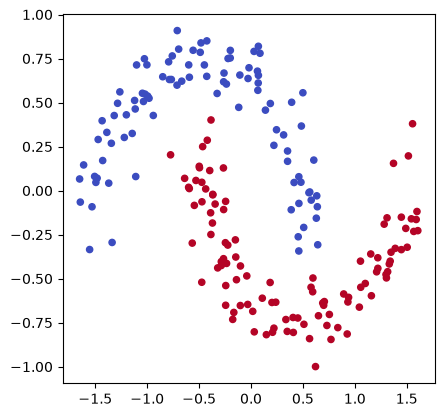

In [3]:
plt.figure(figsize=(4.8, 4.8))
plt.scatter(samples[:, 0], samples[:, 1], c=labels, cmap="coolwarm", s=20)

In [4]:

import pyro
import pyro.distributions as dist
import torch
from pyro.infer import SVI, Predictive, Trace_ELBO, TraceMeanField_ELBO
from pyro.infer.autoguide import (
    AutoNormal,
    init_to_sample,
)
from pyro.optim import Adam as PyroAdam
from pyro.optim import ClippedAdam

from dataclasses import dataclass

import numpy as np

c:\Users\stoennis\Desktop\UQHM\github\last_layer_laplace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
DTYPE: torch.dtype = torch.double
LOG_EVERY: int = 100  # print ELBO loss every N steps
N_STEPS: int = 5000  # default number of SVI optimisation steps

# Each entry: (in_dim, out_dim)
LAYER_DIMS: list[tuple[int, int]] = [(2, 60), (60, 60), (60, 30), (30, 1)]

In [6]:





class BayesianMLP:
    """Pyro probabilistic model for a binary classification MLP.

    Parameters
    ----------
    layer_dims :
        List of (in_dim, out_dim) pairs defining the network architecture.
    prior_scale :
        Standard deviation of all Gaussian weight priors, before the per-layer
        ``sqrt(2 / fan_in)`` correction that keeps pre-activation noise variance
        flat across layer widths.
    elbo_scale :
        Constant multiplying *every* term of the ELBO. Pass ``1 / n_train`` to
        optimise the per-datapoint ELBO, which keeps the loss magnitude (and
        therefore the useful learning-rate range) independent of dataset size
        and makes the printed loss directly comparable to a per-point NLL —
        ``log 2 ≈ 0.693`` is the chance level for balanced binary labels.
    init_scale :
        Initial posterior standard deviation of the mean-field guide.

    """

    def __init__(
        self,
        layer_dims: list[tuple[int, int]],
        prior_scale: float = 0.1,
        *,
        elbo_scale: float = 1.0,
        init_scale: float = 1e-5,
    ) -> None:
        """Initialise and validate configuration."""
        self.layer_dims = layer_dims
        self.prior_scale = prior_scale
        self.elbo_scale = elbo_scale
        self.h_activation = torch.nn.LeakyReLU(negative_slope=0.01)
        self._guide = AutoNormal(
            self.model, init_loc_fn=init_to_sample, init_scale=init_scale
        )

    def _sample_weights(self) -> list[tuple[torch.Tensor, torch.Tensor]]:
        """Draw a (w, b) pair per layer from the fan-in scaled Gaussian priors."""
        params: list[tuple[torch.Tensor, torch.Tensor]] = []
        for i, (in_dim, out_dim) in enumerate(self.layer_dims):
            scale = self.prior_scale * (2.0 / in_dim) ** 0.5
            w = pyro.sample(
                f"w{i}",
                dist.Normal(torch.zeros(out_dim, in_dim, dtype=DTYPE), scale).to_event(
                    2
                ),
            )
            b = pyro.sample(
                f"b{i}",
                dist.Normal(torch.zeros(out_dim, dtype=DTYPE), scale).to_event(1),
            )
            params.append((w, b))
        return params

    def _forward(
        self,
        x: torch.Tensor,
        params: list[tuple[torch.Tensor, torch.Tensor]],
    ) -> torch.Tensor:
        """Run the MLP forward pass and return the logits, shape ``(..., batch)``."""
        h = x
        for i, (w, b) in enumerate(params):
            h = h @ w.transpose(-2, -1) + b[..., None, :]  # (batch, out_dim)
            if i < len(params) - 1:
                h = self.h_activation(h)
        return h.squeeze(-1)

    def model(
        self,
        x: torch.Tensor,
        y: torch.Tensor | None = None,
        kl_scale: float = 1.0,
    ) -> torch.Tensor:
        """Pyro model: sample weights, run forward pass, condition on observations.

        ``self.elbo_scale`` scales the whole objective (ELBO normalization);
        *kl_scale* additionally down-weights only the weight priors, which is the
        model-side half of KL annealing — the guide-side half lives in `guide`.
        """
        with pyro.poutine.scale(scale=self.elbo_scale):
            with pyro.poutine.scale(scale=kl_scale):
                params = self._sample_weights()
            logits = self._forward(x, params)
            pyro.deterministic("logits", logits)
            with pyro.plate("data", x.shape[0]):
                return pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    def guide(
        self,
        x: torch.Tensor,
        y: torch.Tensor | None = None,
        kl_scale: float = 1.0,
    ) -> dict[str, torch.Tensor]:
        """Mean-field guide, scaled to match the model's latent sites.

        The ELBO reads the KL weight off *both* traces — the entropy term from
        the guide site and ``log p(w)`` from the model site — so the annealing
        factor has to be applied on this side as well, or the two halves of the
        KL would be weighted differently.
        """
        with pyro.poutine.scale(scale=self.elbo_scale * kl_scale):
            return self._guide(x, y)


def fit_standardizer(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return the per-column ``(mean, std)`` of *x*, for use with `standardize`.

    Fit on training data only.  Columns with zero variance get ``std = 1`` so
    they standardize to 0 instead of producing NaNs.
    """
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    return mean, np.where(std == 0.0, 1.0, std)


def standardize(x: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """Apply a ``(mean, std)`` standardization from `fit_standardizer` to *x*."""
    return (x - mean) / std


def linear_ramp(
    step: int,
    n_steps: int,
    *,
    start: float = 0.0,
    end: float = 1.0,
) -> float:
    """Interpolate linearly from *start* to *end* over *n_steps*, clamped outside.

    ``step <= 0`` returns *start* and ``step >= n_steps`` returns *end*, so the
    ramp can be offset by passing a shifted step.  ``n_steps <= 0`` disables the
    ramp and returns *end* immediately.
    """
    if n_steps <= 0:
        return end
    frac = min(max(step / n_steps, 0.0), 1.0)
    return start + frac * (end - start)


@dataclass(frozen=True)
class TrainingSchedule:
    """SVI loop length, logging cadence, and the KL annealing ramp.

    KL annealing multiplies the KL term by a factor that is held at *kl_start*
    for *kl_warmup_steps*, then grows linearly to 1 over *kl_anneal_steps*.
    Early training is therefore driven almost entirely by the likelihood, which
    is what stops the guide from collapsing onto the prior before it has fit any
    signal — the failure mode that leaves a converged loss at 0.5 accuracy.

    *kl_start* must stay strictly positive: ``poutine.scale`` rejects a zero
    scale.  Leaving *kl_anneal_steps* at 0 disables annealing (KL weight 1
    throughout), i.e. the plain ELBO.
    """

    n_steps: int = N_STEPS
    log_every: int = LOG_EVERY
    kl_warmup_steps: int = 0
    kl_anneal_steps: int = 0
    kl_start: float = 1e-3

    def kl_scale(self, step: int) -> float:
        """Return the KL weight for 1-based *step*."""
        return linear_ramp(
            step - self.kl_warmup_steps,
            self.kl_anneal_steps,
            start=self.kl_start,
            end=1.0,
        )


def train(
    svi: SVI,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
    schedule: TrainingSchedule,
) -> tuple[list[float], list[float]]:
    """Run an SVI training loop and return the per-step (loss, KL weight) history.

    The caller is responsible for constructing *svi* (model, guide, optimizer,
    and loss bundled together) and for clearing the Pyro param store beforehand
    if separate calls should not share parameter state.

    Losses are per-datapoint whenever the model was built with
    ``elbo_scale=1/n_train``, and are computed against the *annealed* objective,
    so they are only comparable across steps once the KL weight reaches 1.
    """
    losses: list[float] = []
    kl_scales: list[float] = []
    for step in range(1, schedule.n_steps + 1):
        kl_scale = schedule.kl_scale(step)
        loss = svi.step(x_train, y_train, kl_scale=kl_scale)
        losses.append(loss)
        kl_scales.append(kl_scale)
        if step % schedule.log_every == 0:
            print(
                f"    step {step:>6}/{schedule.n_steps}"
                f"  ELBO/point: {loss:>12.5f}"
                f"  KL weight: {kl_scale:>7.4f}"
            )

    return losses, kl_scales


In [7]:
x_train, y_train = samples, labels

pyro.clear_param_store()


schedule = TrainingSchedule(
        n_steps=30000,
        log_every=1000,
        kl_warmup_steps=1000,
        kl_anneal_steps=9000,
        kl_start=1e-3,
    )

initial_lr = 0.001
gamma = 0.1  # final learning rate will be gamma * initial_lr
lrd = gamma ** (1 / schedule.n_steps)

BNN = BayesianMLP(
        layer_dims=LAYER_DIMS,
        # With standardized inputs the per-layer sqrt(2/fan_in) factor makes
        # prior_scale=1.0 a He-style prior, i.e. O(1) prior-predictive logits.
        prior_scale=1.0,
        elbo_scale=1.0 / x_train.shape[0],  # per-datapoint ELBO
    )

svi = SVI(
        BNN.model,
        BNN.guide,
        # ClippedAdam, not plain Adam: only it accepts `lrd` (per-step LR decay),
        # and its gradient clipping is a cheap guard against the occasional huge
        # step out of a bad init.  `eps` sits below the normalized gradient
        # magnitudes so Adam stays scale invariant and `initial_lr` keeps the
        # meaning it had before ELBO normalization.
        ClippedAdam({"lr": initial_lr, "lrd": lrd, "eps": 1e-12, "clip_norm": 10.0}),
        loss=TraceMeanField_ELBO(num_particles=1, vectorize_particles=True),
    )

losses, _ = train(svi, x_train, y_train, schedule)

    step   1000/30000  ELBO/point:      0.25132  KL weight:  0.0010
    step   2000/30000  ELBO/point:     87.99315  KL weight:  0.5005
    step   3000/30000  ELBO/point:    137.51141  KL weight:  1.0000
    step   4000/30000  ELBO/point:    110.64933  KL weight:  1.0000
    step   5000/30000  ELBO/point:     89.03138  KL weight:  1.0000
    step   6000/30000  ELBO/point:     69.78021  KL weight:  1.0000
    step   7000/30000  ELBO/point:     52.64047  KL weight:  1.0000
    step   8000/30000  ELBO/point:     37.24919  KL weight:  1.0000
    step   9000/30000  ELBO/point:     23.83145  KL weight:  1.0000
    step  10000/30000  ELBO/point:     13.24138  KL weight:  1.0000
    step  11000/30000  ELBO/point:      6.44181  KL weight:  1.0000
    step  12000/30000  ELBO/point:      3.31195  KL weight:  1.0000
    step  13000/30000  ELBO/point:      2.34479  KL weight:  1.0000
    step  14000/30000  ELBO/point:      1.43395  KL weight:  1.0000
    step  15000/30000  ELBO/point:      1.40967 

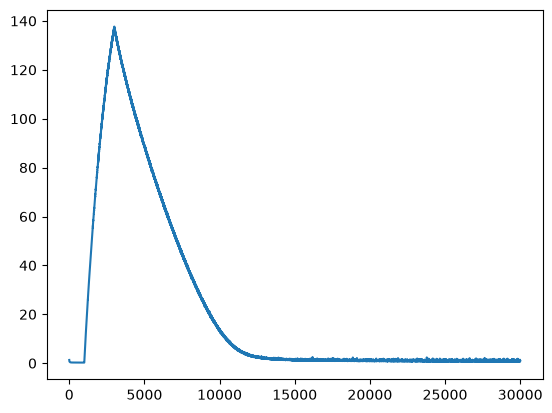

In [9]:
plt.plot(losses)

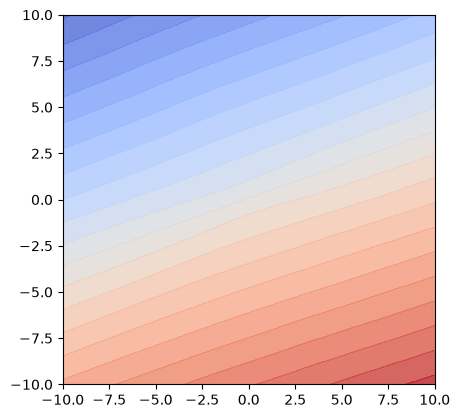

In [10]:
x1 = torch.linspace(-10, 10, 100)
x2 = torch.linspace(-10, 10, 100)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

X = torch.stack((X1.flatten(), X2.flatten()), dim=-1)

predictive = Predictive(
    BNN.model,
    guide=BNN.guide,
    num_samples=1000,
    return_sites=("logits",),
)

samples = predictive(X, None, kl_scale=1.0)

logits = samples["logits"].mean(dim=0).reshape(X1.shape)

plt.figure(figsize=(4.8, 4.8))
plt.contourf(X1, X2, logits.detach().numpy(), levels=20, cmap="coolwarm", alpha=0.8)